## Transformer Evaluation and Comparison
---

In [7]:
import pandas as pd

predictions_df = pd.read_csv(
    "../data/transformer_predictions.csv"
)

print(predictions_df.head())
print("Number of test articles:", len(predictions_df))

   Unnamed: 0                                              title  \
0       65712                                                NaN   
1       14826  U.S. lawmakers push for answers on Trump team'...   
2       47187  WH Sources: Reince Priebus Is Sh**tting His Pa...   
3       15867  Arizona Secretary Of State Confirms Election F...   
4        1995  US Spends Over $500 Million To Train Syrian Re...   

                                                text  label  \
0  Also, since when did we start using "non-GAAP"...      1   
1  WASHINGTON (Reuters) - A crisis over the relat...      0   
2  The investigation into possible collusion betw...      1   
3  Monday s hearing on voter suppression and elec...      1   
4  It apparently wasn t shocking enough when the ...      1   

                                           full_text  \
0  Also, since when did we start using "non-GAAP"...   
1  U.S. lawmakers push for answers on Trump team'...   
2  WH Sources: Reince Priebus Is Sh**tting H

In [18]:
full_df = pd.read_csv(
    "../data/processed/WELFake_processed.csv"
)

print("Full dataset:", full_df.shape)

Full dataset: (62704, 14)


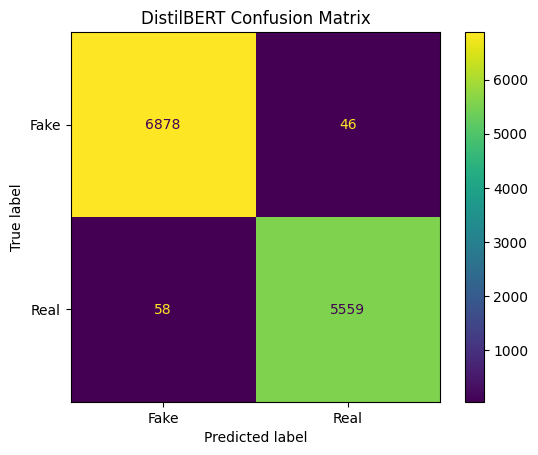

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    predictions_df["label"],
    predictions_df["predicted_label"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()

plt.title("DistilBERT Confusion Matrix")
plt.show()


In [9]:
errors_only = predictions_df[
    predictions_df["label"] != predictions_df["predicted_label"]
].copy()

print("Total errors:", len(errors_only))

Total errors: 104


In [10]:
real_predicted_fake = errors_only[
    (errors_only["label"] == 1) &
    (errors_only["predicted_label"] == 0)
]

fake_predicted_real = errors_only[
    (errors_only["label"] == 0) &
    (errors_only["predicted_label"] == 1)
]

print("Real → Fake:", len(real_predicted_fake))
print("Fake → Real:", len(fake_predicted_real))

Real → Fake: 58
Fake → Real: 46


Checking if the article appears in both training and testing

In [19]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    full_df,
    test_size=0.20,
    random_state=42,
    stratify=full_df["label"]
)

train_texts = set(train_df["text"])
test_texts = set(test_df["text"])

overlap = train_texts.intersection(test_texts)

print("Exact train/test text overlap:", len(overlap))

Exact train/test text overlap: 0


In [14]:
for _, row in errors_only.head(10).iterrows():
    print("=" * 80)
    print("TITLE:", row["title"])
    print("ACTUAL:", row["label"])
    print("PREDICTED:", row["predicted_label"])
    print()
    print(row["text"][:1000])
    print()

TITLE: Let’s Not Kid Ourselves… What Hillary Clinton Did Is a Federal Crime
ACTUAL: 1
PREDICTED: 0

This is not a close call.
It is not a judgement call.
It is not subject to interpretation.
It is a flat-out criminal offense. 
As secretary of state, Hillary Clinton routinely asked her maid to print out sensitive government e-mails and documents — including ones containing classified information — from her house in Washington, DC, e-mails and FBI memos show. But the housekeeper lacked the security clearance to handle such material.
In fact, Marina Santos was called on so frequently to receive e-mails that she may hold the secrets to E-mailgate — if only the FBI and Congress would subpoena her and the equipment she used.
It is a crime to knowingly, say much less intentionally, give access to classified information to someone who is not cleared to receive and handle it.
Santos also had access to a highly secure room called an SCIF (sensitive compartmented information facility) that diplom